## Step 1: Explore Our Data

In [5]:
from explore import load_sample, inspect_mask, binarize, plot_comparison, polyp_coverage

IMG_DIR  = "data/Kvasir-SEG/images"
MASK_DIR = "data/Kvasir-SEG/masks"

img, mask, name = load_sample(IMG_DIR, MASK_DIR)
inspect_mask(mask)

Name : cju0qkwl35piu0993l0dewei2.jpg
Image: size=(622, 529)  mode=RGB
Mask : size=(622, 529)  mode=RGB
Min: 0  Max: 255
Unique values: [  0   1   2   3   4   5   6   7   8 247 248 249 250 251 252 253 254 255]


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(529, 622, 3), dtype=uint8)

Unique values after binarize: [0 1]


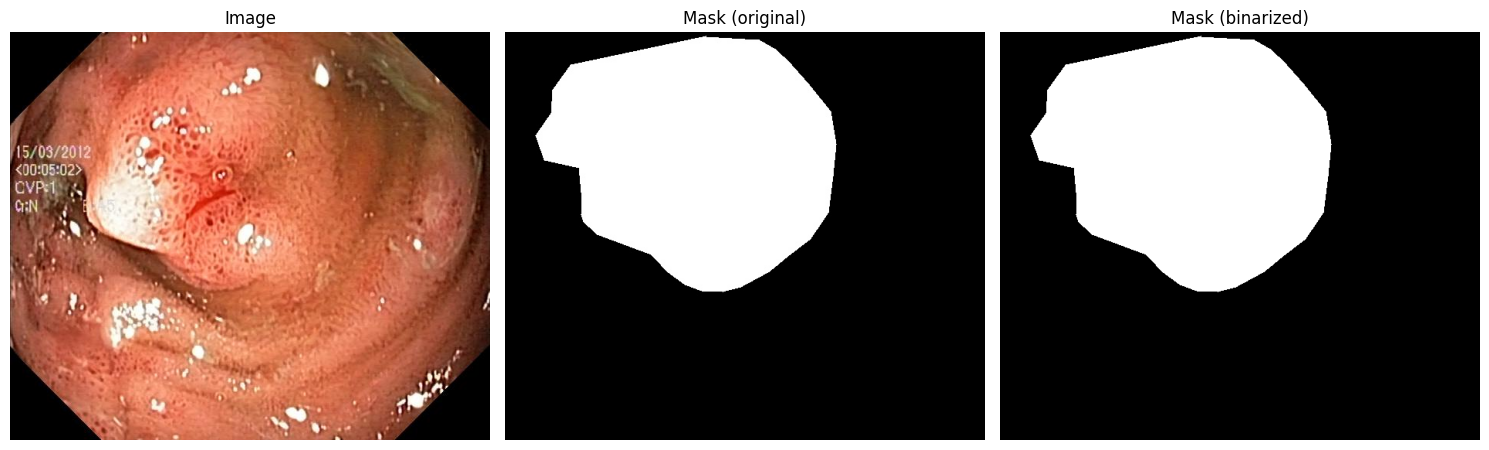

In [6]:
binary_mask = binarize(mask)
plot_comparison(img, mask, binary_mask)

In [7]:
print(f"Polyp coverage: {polyp_coverage(binary_mask):.2%}")

Polyp coverage: 28.28%


## Step 2: Dataset & DataLoaders

In [8]:
import torch
from dataset import build_dataloaders

IMG_DIR  = "data/Kvasir-SEG/images"
MASK_DIR = "data/Kvasir-SEG/masks"

train_loader, val_loader, test_loader = build_dataloaders(
    img_dir=IMG_DIR,
    mask_dir=MASK_DIR,
    batch_size=8,
    num_workers=2,
)

In [9]:
print(f"Train: {len(train_loader.dataset)} samples, {len(train_loader)} batches")
print(f"Val  : {len(val_loader.dataset)} samples")
print(f"Test : {len(test_loader.dataset)} samples")

imgs, masks = next(iter(train_loader))
print(f"\nImage batch shape : {imgs.shape}   dtype: {imgs.dtype}")
print(f"Mask  batch shape : {masks.shape}  dtype: {masks.dtype}")
print(f"Image value range : [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"Mask unique values: {masks.unique().tolist()}")

assert imgs.shape  == (8, 3, 256, 256)
assert masks.shape == (8, 1, 256, 256)
assert imgs.dtype  == torch.float32
assert masks.dtype == torch.float32
assert set(masks.unique().tolist()).issubset({0.0, 1.0})
assert len(train_loader.dataset) == 800
assert len(val_loader.dataset)   == 100
assert len(test_loader.dataset)  == 100
print("\nAll assertions passed.")

Train: 800 samples, 100 batches
Val  : 100 samples
Test : 100 samples

Image batch shape : torch.Size([8, 3, 256, 256])   dtype: torch.float32
Mask  batch shape : torch.Size([8, 1, 256, 256])  dtype: torch.float32
Image value range : [-2.118, 2.640]
Mask unique values: [0.0, 1.0]

All assertions passed.


In [10]:
from dataset import split_dataset

train_paths = set(train_loader.dataset.img_paths)
val_paths   = set(val_loader.dataset.img_paths)
test_paths  = set(test_loader.dataset.img_paths)

assert len(train_paths & val_paths)  == 0
assert len(train_paths & test_paths) == 0
assert len(val_paths   & test_paths) == 0
print("No overlap between splits.")

No overlap between splits.


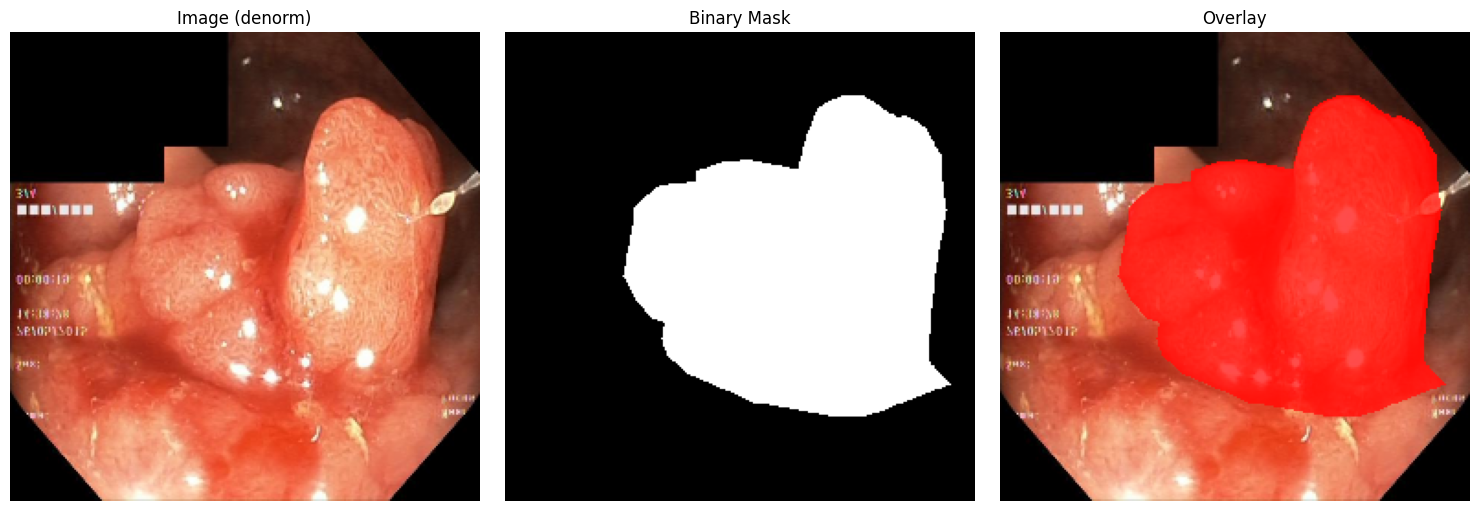

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.numpy().transpose(1, 2, 0)  # [C,H,W] -> [H,W,C]
    return np.clip(img * std + mean, 0, 1)

img_t, mask_t = imgs[0], masks[0]
img_disp  = denormalize(img_t)
mask_disp = mask_t.squeeze().numpy()

overlay = img_disp.copy()
overlay[mask_disp == 1, 0] = 1.0   # red channel max where polyp
overlay[mask_disp == 1, 1] *= 0.3
overlay[mask_disp == 1, 2] *= 0.3

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_disp);             axes[0].set_title("Image (denorm)")
axes[1].imshow(mask_disp, cmap="gray"); axes[1].set_title("Binary Mask")
axes[2].imshow(overlay);              axes[2].set_title("Overlay")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 3: UNet Model

In [12]:
import torch
from model import UNet

model = UNet(in_channels=3, out_channels=1)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters    : 31,384,833
Trainable parameters: 31,384,833


In [13]:
dummy = torch.zeros(2, 3, 256, 256)
with torch.no_grad():
    out = model(dummy)

print(f"Input  shape: {dummy.shape}")
print(f"Output shape: {out.shape}")

assert out.shape == (2, 1, 256, 256), f"Unexpected output shape: {out.shape}"
print("Shape assertion passed.")

Input  shape: torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])
Shape assertion passed.


## Step 4: Loss Function

In [14]:
import torch
from loss import BCEDiceLoss

criterion = BCEDiceLoss(bce_weight=0.5, dice_weight=0.5)

# Perfect prediction: logits very positive where target=1, very negative where target=0
perfect_logits = torch.tensor([[[[10.0, -10.0], [-10.0, 10.0]]]])
target         = torch.tensor([[[[1.0,   0.0],  [ 0.0,  1.0]]]])

loss_perfect = criterion(perfect_logits, target)
print(f"Loss (perfect prediction) : {loss_perfect.item():.6f}  ← should be near 0")

# Random prediction: logits all zero → sigmoid = 0.5 everywhere
random_logits = torch.zeros_like(target)
loss_random   = criterion(random_logits, target)
print(f"Loss (random prediction)  : {loss_random.item():.6f}  ← should be higher")

assert loss_perfect < loss_random, "Perfect prediction should have lower loss than random"
print("\nAssertion passed.")

Loss (perfect prediction) : 0.000041  ← should be near 0
Loss (random prediction)  : 0.546574  ← should be higher

Assertion passed.


## Step 5: Metrics

In [15]:
import torch
from metrics import dice_score, iou_score

# Perfect prediction
perfect_logits = torch.tensor([[[[10.0, -10.0], [-10.0, 10.0]]]])
target         = torch.tensor([[[[1.0,   0.0],  [ 0.0,  1.0]]]])

print(f"Dice (perfect): {dice_score(perfect_logits, target):.4f}  ← should be 1.0")
print(f"IoU  (perfect): {iou_score(perfect_logits,  target):.4f}  ← should be 1.0")

# Random prediction (logits = 0 → sigmoid = 0.5 → thresholded to 1 everywhere)
random_logits = torch.zeros_like(target)
print(f"\nDice (random) : {dice_score(random_logits, target):.4f}  ← should be < 1.0")
print(f"IoU  (random) : {iou_score(random_logits,  target):.4f}  ← should be < 1.0")

# Edge case: both prediction and target are empty → score should be 1.0
empty_logits = torch.full((1, 1, 2, 2), -10.0)
empty_target = torch.zeros(1, 1, 2, 2)
print(f"\nDice (both empty): {dice_score(empty_logits, empty_target):.4f}  ← should be 1.0")
print(f"IoU  (both empty): {iou_score(empty_logits,  empty_target):.4f}  ← should be 1.0")

assert dice_score(perfect_logits, target) == 1.0
assert iou_score(perfect_logits,  target) == 1.0
assert dice_score(empty_logits, empty_target) == 1.0
assert iou_score(empty_logits,  empty_target) == 1.0
print("\nAll assertions passed.")

Dice (perfect): 1.0000  ← should be 1.0
IoU  (perfect): 1.0000  ← should be 1.0

Dice (random) : 0.0000  ← should be < 1.0
IoU  (random) : 0.0000  ← should be < 1.0

Dice (both empty): 1.0000  ← should be 1.0
IoU  (both empty): 1.0000  ← should be 1.0

All assertions passed.


## Step 6: Training Loop

In [ ]:
import torch
import torch.optim as optim
from dataset import build_dataloaders
from model import UNet
from loss import BCEDiceLoss
from train import DEVICE, overfit_one_batch

IMG_DIR  = "data/Kvasir-SEG/images"
MASK_DIR = "data/Kvasir-SEG/masks"

train_loader, val_loader, test_loader = build_dataloaders(IMG_DIR, MASK_DIR, batch_size=8)

# Fresh model for sanity check — if loss doesn't drop, something is wired wrong
sanity_model     = UNet().to(DEVICE)
sanity_optimizer = optim.Adam(sanity_model.parameters(), lr=1e-3)
sanity_criterion = BCEDiceLoss()

overfit_one_batch(sanity_model, train_loader, sanity_criterion, sanity_optimizer, DEVICE)

In [ ]:
from train import train

model     = UNet().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = BCEDiceLoss()

history = train(model, train_loader, val_loader, optimizer, criterion, DEVICE)

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, history["train_loss"], label="train loss")
ax1.plot(epochs, history["val_loss"],   label="val loss")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(epochs, history["val_dice"], label="val Dice")
ax2.plot(epochs, history["val_iou"],  label="val IoU")
ax2.set_title("Metrics"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()

print(f"Best val Dice : {max(history['val_dice']):.4f}")
print(f"Best val IoU  : {max(history['val_iou']):.4f}")